# Day 3 - Machine Learning Fundamentals

## Objective

In this notebook, I explore the core concepts of Machine Learning by understanding the difference between Regression and Classification, building predictive models, evaluating their performance, understanding overfitting, performing cross-validation, tuning hyperparameters, and comparing ensemble models.

This notebook is based on the concepts learned during the NVIDIA AI GPU Summer Internship.

## 1. Import Libraries

First, we import all the required Python libraries for data analysis, visualization, machine learning, and model evaluation.

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import (
    load_diabetes,
    load_breast_cancer
)

from sklearn.model_selection import train_test_split

print("Setup Complete ✅")

Setup Complete ✅


## 2. Regression vs Classification

Machine Learning problems are generally divided into two categories:

- **Regression** predicts continuous numerical values.
- **Classification** predicts discrete categories or labels.

To understand the difference, we use two built-in datasets from Scikit-learn.

In [29]:
diabetes = load_diabetes(as_frame=True)

X_reg = diabetes.data

y_reg = diabetes.target

In [10]:
print("Shape:", df.shape)

df.info()

Shape: (891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    float64
 5   Parch     891 non-null    float64
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 55.8 KB


In [30]:
cancer = load_breast_cancer(as_frame=True)

X_clf = cancer.data

y_clf = cancer.target

In [31]:
print("Regression Dataset")

print(X_reg.shape)

print(y_reg.head())

Regression Dataset
(442, 10)
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


In [32]:
print("Classification Dataset")

print(X_clf.shape)

print(y_clf.value_counts())

Classification Dataset
(569, 30)
target
1    357
0    212
Name: count, dtype: int64


## 3. Visualizing the Target Variables

Regression targets are continuous values, while classification targets belong to a limited number of classes.

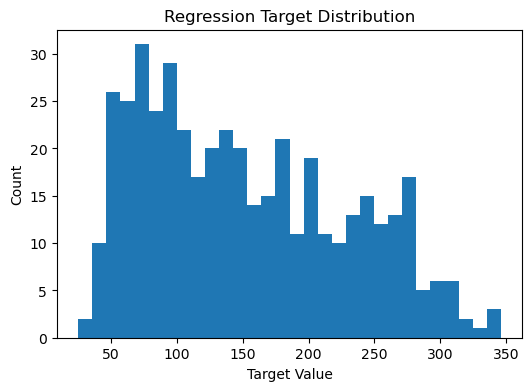

In [86]:
plt.figure(figsize=(6,4))

plt.hist(y_reg, bins=30)

plt.title("Regression Target Distribution")

plt.xlabel("Target Value")

plt.ylabel("Count")

plt.savefig(
    "images/regression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

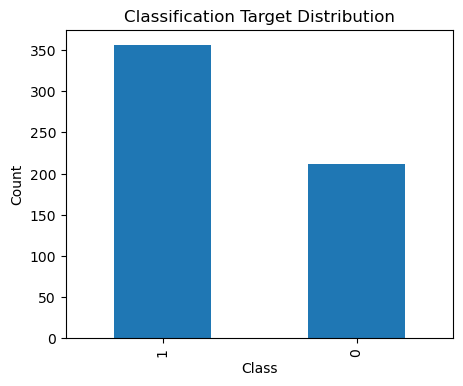

In [87]:
plt.figure(figsize=(5,4))

y_clf.value_counts().plot(kind="bar")

plt.title("Classification Target Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.savefig("images/classification_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Building Our First Machine Learning Models

After understanding the difference between Regression and Classification, the next step is to train our first machine learning models.

We will:

- Split the datasets into training and testing sets
- Train a Linear Regression model
- Train a Logistic Regression model
- Compare predictions with actual values

In [35]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [36]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression Dataset")

print("Training Samples :", Xr_train.shape[0])

print("Testing Samples  :", Xr_test.shape[0])

Regression Dataset
Training Samples : 353
Testing Samples  : 89


In [37]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("Classification Dataset")

print("Training Samples :", Xc_train.shape[0])

print("Testing Samples  :", Xc_test.shape[0])

Classification Dataset
Training Samples : 455
Testing Samples  : 114


In [38]:
linear_model = LinearRegression()

linear_model.fit(
    Xr_train,
    yr_train
)

yr_pred = linear_model.predict(Xr_test)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


### Comparing Predictions

Let's compare the predicted values with the actual values.

In [39]:
comparison = pd.DataFrame({

    "Actual": yr_test.values[:10],

    "Predicted": yr_pred[:10]

})

comparison

,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


In [40]:
logistic_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))

])

In [41]:
logistic_pipeline.fit(
    Xc_train,
    yc_train
)

yc_pred = logistic_pipeline.predict(Xc_test)

yc_probability = logistic_pipeline.predict_proba(Xc_test)[:,1]

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [42]:
classification_preview = pd.DataFrame({

    "Actual Label": yc_test.values[:10],

    "Predicted Label": yc_pred[:10],

    "Probability": yc_probability[:10]

})

classification_preview

,Actual Label,Predicted Label,Probability
0,0,0,5.888242e-08
1,1,1,9.999887e-01
2,0,0,6.410825e-03
3,1,1,5.335085e-01
4,0,0,6.525001e-10
5,1,1,9.921604e-01
6,1,1,9.999828e-01
7,0,0,5.635275e-07
8,0,0,5.431637e-05
9,0,0,8.041849e-11


## Key Learning

- Regression predicts continuous numerical values.
- Classification predicts categories or classes.
- Train-test split helps evaluate model performance on unseen data.
- Pipelines combine preprocessing and model training into one workflow.

# 5. Model Evaluation

After training a machine learning model, it is important to evaluate how well it performs.

Different metrics are used for Regression and Classification tasks.

### Regression Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

### Classification Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- AUC Score

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,

    confusion_matrix,
    ConfusionMatrixDisplay,

    roc_auc_score,
    RocCurveDisplay
)

In [44]:
mae = mean_absolute_error(yr_test, yr_pred)

mse = mean_squared_error(yr_test, yr_pred)

rmse = root_mean_squared_error(yr_test, yr_pred)

r2 = r2_score(yr_test, yr_pred)

print("Regression Performance")
print("-"*40)

print("MAE  :", round(mae,2))
print("MSE  :", round(mse,2))
print("RMSE :", round(rmse,2))
print("R²   :", round(r2,3))

Regression Performance
----------------------------------------
MAE  : 42.79
MSE  : 2900.19
RMSE : 53.85
R²   : 0.453


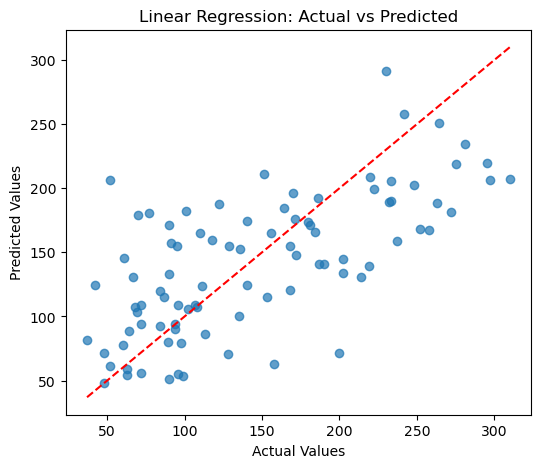

In [88]:
plt.figure(figsize=(6,5))

plt.scatter(
    yr_test,
    yr_pred,
    alpha=0.7
)

plt.plot(
    [yr_test.min(), yr_test.max()],
    [yr_test.min(), yr_test.max()],
    "r--"
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Linear Regression: Actual vs Predicted")

plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

In [46]:
accuracy = accuracy_score(
    yc_test,
    yc_pred
)

precision = precision_score(
    yc_test,
    yc_pred
)

recall = recall_score(
    yc_test,
    yc_pred
)

f1 = f1_score(
    yc_test,
    yc_pred)

print("Classification Performance")
print("-"*40)

print("Accuracy :", round(accuracy,3))

print("Precision:", round(precision,3))

print("Recall   :", round(recall,3))

print("F1 Score :", round(f1,3))

Classification Performance
----------------------------------------
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1 Score : 0.986


In [47]:
print(
    classification_report(
        yc_test,
        yc_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



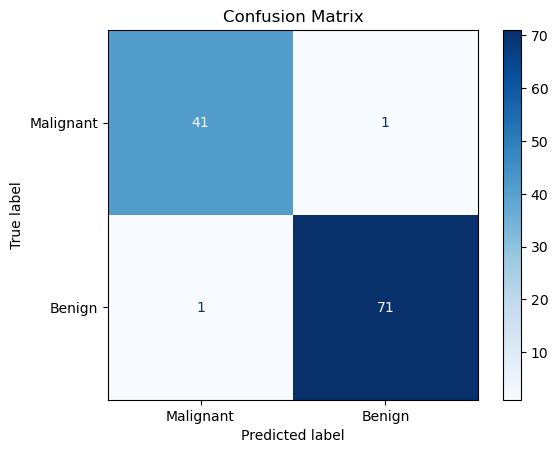

In [89]:
cm = confusion_matrix(
    yc_test,
    yc_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

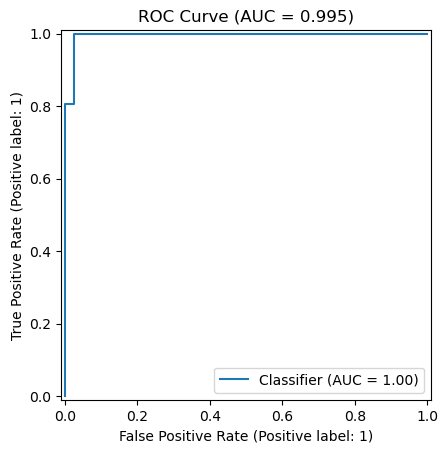

In [90]:
auc = roc_auc_score(
    yc_test,
    yc_probability
)

RocCurveDisplay.from_predictions(
    yc_test,
    yc_probability
)

plt.title(
    f"ROC Curve (AUC = {auc:.3f})"
)
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Learning

Regression models are evaluated using error-based metrics.

Classification models are evaluated using class-based metrics.

The ROC Curve and AUC Score help determine how well a classifier distinguishes between different classes.

# 6. Overfitting and Underfitting

One of the biggest challenges in Machine Learning is finding the right model complexity.

- **Underfitting** occurs when the model is too simple and cannot capture the underlying patterns in the data.
- **Overfitting** occurs when the model learns the training data too well, including noise, and performs poorly on new data.

In this section, we will use a Decision Tree to observe how model complexity affects performance.

In [50]:
from sklearn.tree import DecisionTreeRegressor

In [51]:
depths = range(1, 21)

train_rmse = []
test_rmse = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(Xr_train, yr_train)

    train_prediction = model.predict(Xr_train)

    test_prediction = model.predict(Xr_test)

    train_rmse.append(
        root_mean_squared_error(
            yr_train,
            train_prediction
        )
    )

    test_rmse.append(
        root_mean_squared_error(
            yr_test,
            test_prediction
        )
    )

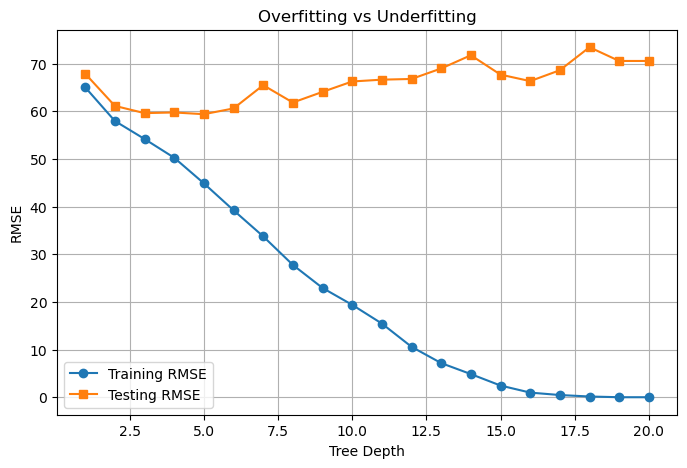

In [91]:
plt.figure(figsize=(8,5))

plt.plot(
    depths,
    train_rmse,
    marker="o",
    label="Training RMSE"
)

plt.plot(
    depths,
    test_rmse,
    marker="s",
    label="Testing RMSE"
)

plt.xlabel("Tree Depth")

plt.ylabel("RMSE")

plt.title("Overfitting vs Underfitting")

plt.legend()

plt.grid(True)

plt.savefig("images/overfitting_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [53]:
best_depth = depths[np.argmin(test_rmse)]

print("Best Tree Depth :", best_depth)

Best Tree Depth : 5


### Interpretation

- At lower tree depths, both training and testing errors are high (underfitting).
- As tree depth increases, testing error decreases until an optimal depth.
- Beyond that point, training error continues to decrease while testing error increases.
- This increase in testing error indicates overfitting.

# 7. Validation Curve

Validation curves help us choose an appropriate model complexity by comparing training accuracy and validation accuracy.

In [54]:
from sklearn.model_selection import validation_curve
from sklearn.tree import DecisionTreeClassifier

In [55]:
parameter_range = range(1,16)

train_scores, validation_scores = validation_curve(

    DecisionTreeClassifier(
        random_state=42
    ),

    Xc_train,

    yc_train,

    param_name="max_depth",

    param_range=parameter_range,

    cv=5,

    scoring="accuracy"
)

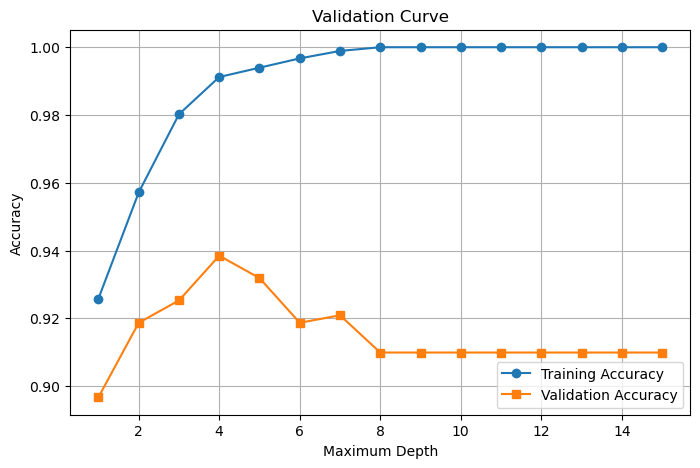

In [92]:
plt.figure(figsize=(8,5))

plt.plot(
    parameter_range,
    train_scores.mean(axis=1),
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    parameter_range,
    validation_scores.mean(axis=1),
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Maximum Depth")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.grid(True)

plt.savefig("images/validation_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Key Learning

- A small gap between training and validation accuracy indicates a well-generalized model.
- A large gap suggests overfitting.
- Validation curves help in selecting the right model complexity.

# 8. Cross Validation

Train-test split gives us one estimate of model performance.

Cross Validation evaluates the model on multiple train-test splits, providing a more reliable estimate of how well the model generalizes to unseen data.

In [57]:
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    cross_validate
)

In [58]:
cv_scores = cross_val_score(

    LinearRegression(),

    Xr_train,

    yr_train,

    cv=5,

    scoring="neg_root_mean_squared_error"

)

rmse_scores = -cv_scores

print("RMSE for each fold")

print(rmse_scores)

print()

print("Average RMSE :", round(rmse_scores.mean(),2))

print("Standard Deviation :", round(rmse_scores.std(),2))

RMSE for each fold
[52.53034465 58.93522481 52.08727478 56.50041896 59.80716652]

Average RMSE : 55.97
Standard Deviation : 3.18


### Interpretation

Lower RMSE indicates better regression performance.

A smaller standard deviation means the model performs consistently across different data splits.

In [59]:
skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

In [60]:
metrics = [

    "accuracy",

    "precision",

    "recall",

    "f1",

    "roc_auc"

]

In [61]:
cv_results = cross_validate(

    logistic_pipeline,

    Xc_train,

    yc_train,

    cv=skf,

    scoring=metrics
)

In [62]:
summary = pd.DataFrame({

    metric:[

        cv_results[f"test_{metric}"].mean(),

        cv_results[f"test_{metric}"].std()

    ]

    for metric in metrics

},

index=["Mean","Standard Deviation"])

summary.T

,Mean,Standard Deviation
accuracy,0.978022,0.009829
precision,0.979472,0.016229
recall,0.985965,0.013129
f1,0.982544,0.007752
roc_auc,0.995872,0.004960


## Key Learning

Cross Validation provides a more dependable estimate of model performance than a single train-test split.

Stratified K-Fold ensures that each fold maintains the same class distribution, making evaluation more reliable for classification problems.

# 9. Hyperparameter Tuning

Hyperparameters control the behavior of machine learning algorithms.

GridSearchCV systematically tests different combinations of hyperparameters and selects the best-performing model using cross-validation.

In [63]:
from sklearn.model_selection import GridSearchCV

In [64]:
tree_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("classifier",

     DecisionTreeClassifier(

         random_state=42

     ))

])

In [65]:
parameter_grid = {

    "classifier__max_depth":[

        2,

        3,

        4,

        5,

        6,

        8,

        None

    ],

    "classifier__min_samples_leaf":[

        1,

        3,

        5,

        10

    ]
}

In [66]:
grid_search = GridSearchCV(

    tree_pipeline,

    parameter_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid_search.fit(

    Xc_train,

    yc_train
)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 3, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [67]:
print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best F1 Score")

print(round(grid_search.best_score_,3))

Best Parameters
{'classifier__max_depth': 4, 'classifier__min_samples_leaf': 1}

Best F1 Score
0.951


In [68]:
results = pd.DataFrame(

    grid_search.cv_results_

)

results.sort_values(

    "rank_test_score"

).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
8,0.005216,0.000948,0.001275,0.000043,4,1,"{'classifier__max_depth': 4, 'classifier__min_...",0.947368,0.954955,0.931034,0.949153,0.974359,0.951374,0.013970,1
14,0.005771,0.002217,0.002393,0.000988,5,5,"{'classifier__max_depth': 5, 'classifier__min_...",0.947368,0.954955,0.948276,0.925620,0.973913,0.950026,0.015496,2
21,0.005944,0.002345,0.001356,0.000204,8,3,"{'classifier__max_depth': 8, 'classifier__min_...",0.938053,0.954955,0.940171,0.949153,0.965517,0.949570,0.010045,3
13,0.006485,0.002003,0.001952,0.000746,5,3,"{'classifier__max_depth': 5, 'classifier__min_...",0.938053,0.954955,0.940171,0.949153,0.965517,0.949570,0.010045,3
25,0.005157,0.000835,0.001709,0.000677,None,3,"{'classifier__max_depth': None, 'classifier__m...",0.938053,0.954955,0.940171,0.949153,0.965517,0.949570,0.010045,3


# 10. Ensemble Learning - Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Unlike a single Decision Tree, Random Forest builds many trees and combines their predictions, making it more robust and reliable.

In [69]:
from sklearn.ensemble import RandomForestClassifier

In [70]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    Xc_train,
    yc_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
rf_prediction = random_forest.predict(Xc_test)

rf_probability = random_forest.predict_proba(Xc_test)[:,1]

In [72]:
rf_accuracy = accuracy_score(
    yc_test,
    rf_prediction
)

print("Random Forest Accuracy :", round(rf_accuracy,3))

Random Forest Accuracy : 0.956


In [73]:
print(classification_report(
    yc_test,
    rf_prediction
))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



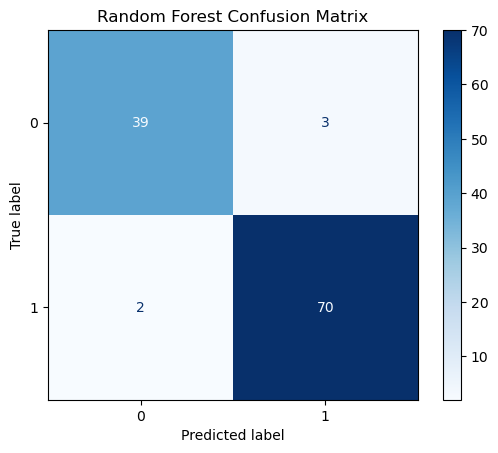

In [74]:
ConfusionMatrixDisplay.from_predictions(
    yc_test,
    rf_prediction,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

# 11. Feature Importance

Feature Importance indicates which features contribute the most to the model's predictions.

This helps us understand the behavior of the trained model.

In [75]:
importance = pd.Series(

    random_forest.feature_importances_,

    index=X_clf.columns

)

importance = importance.sort_values(
    ascending=False
)

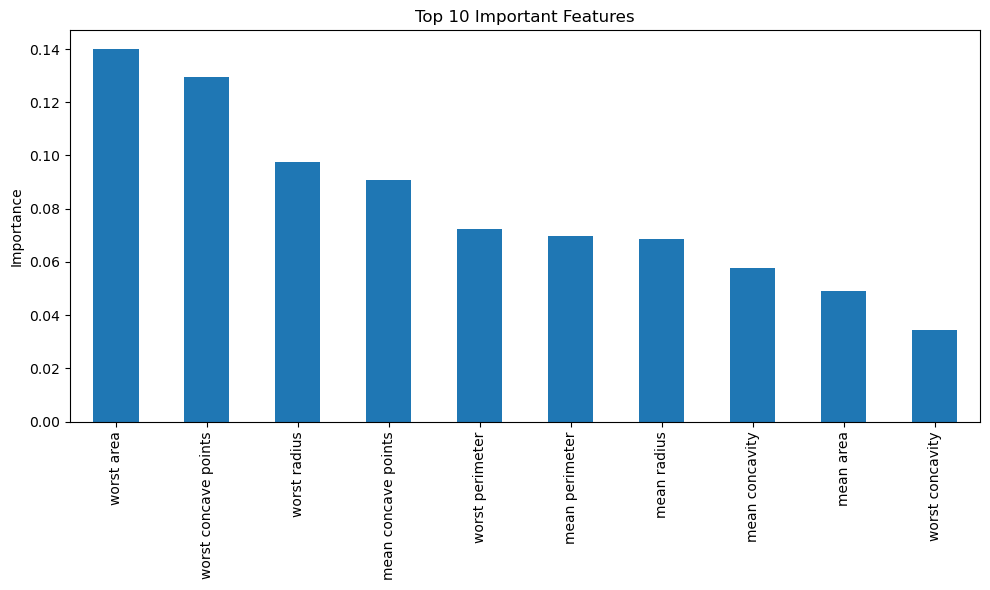

In [93]:
plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="bar"
)

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

# 12. Comparing Models

Now let's compare the performance of the models built in this notebook.

In [77]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy,

        accuracy_score(
            yc_test,
            grid_search.predict(Xc_test)
        ),

        rf_accuracy

    ]

})

comparison

,Model,Accuracy
0,Logistic Regression,0.982456
1,Decision Tree,0.938596
2,Random Forest,0.956140


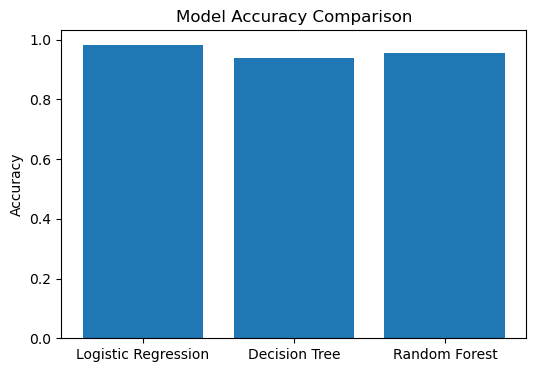

In [94]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")
plt.savefig("images/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 13. Saving the Best Model

Saving a trained model allows it to be reused later without retraining.

We use the Joblib library to serialize the model.

In [79]:
import joblib

In [80]:
joblib.dump(

    random_forest,

    "models/random_forest_model.pkl"

)

print("Model Saved Successfully!")

Model Saved Successfully!


In [81]:
loaded_model = joblib.load(

    "models/random_forest_model.pkl"

)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [82]:
loaded_prediction = loaded_model.predict(
    Xc_test.iloc[:5]
)

print("Predictions")

print(loaded_prediction)

print()

print("Actual")

print(yc_test.iloc[:5].values)

Predictions
[0 1 0 0 0]

Actual
[0 1 0 1 0]


# Conclusion

In this notebook, I explored the complete Machine Learning workflow.

### Concepts Covered

- Regression vs Classification
- Train-Test Split
- Linear Regression
- Logistic Regression
- Pipelines
- Model Evaluation
- Confusion Matrix
- ROC Curve
- Overfitting and Underfitting
- Validation Curve
- Cross Validation
- Hyperparameter Tuning
- Random Forest
- Feature Importance
- Model Saving

### Key Learning

Machine Learning is not only about training models but also about evaluating, tuning, comparing, and deploying them effectively.

In [83]:
summary.T.to_csv(
    "results/cross_validation_results.csv"
)

print("Cross Validation Results Saved")

Cross Validation Results Saved


In [84]:
results.to_csv(
    "results/grid_search_results.csv",
    index=False
)

print("Grid Search Results Saved")

Grid Search Results Saved


In [85]:
plt.savefig(
    "images/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>